In [28]:
import pandas as pd
import glob
import csky as cy
from csky.utils import Arrays
import matplotlib.pyplot as plt
import histlite as hl
from pathlib import Path
import math
import re
import json
import os
import numpy as np
import sys
sys.path.append(os.path.abspath("../../../")) 
from matplotlib.ticker import LogLocator, NullFormatter
from kingmaker_fork.kingmaker.wrapper import KingSpatialLikelihood
from kingmaker_fork.likelihood_analysis.utils.trial_runner_config_loading import restore_king_trial_runner
from kingmaker_fork.likelihood_analysis.utils.parallel_king_trials import get_many_fits_from_trials


from csky_gfu_tests.custom_gfu_specs import GFUDataSpecs as custom_gfu

In [4]:
timer = cy.timing.Timer()
time = timer.time

## Load cached Analysis

In [5]:
repo_cache = cy.utils.ensure_dir('/data/user/fkrafft/csky_repo')
repo = cy.selections.Repository(
    local_root= repo_cache,
    remote_root= '/data/ana/PointSource/GFU/online_v001-p10')

ana_dir = cy.utils.ensure_dir('/data/user/fkrafft/csky_gfu_tests')
with time('ana setup (from cache-to-disk)'):
    ana = cy.get_analysis(repo, 'version-001-p09' , custom_gfu.gfu_11yr, dir = ana_dir)

Setting up Analysis for:
GFU_2011_2022
Setting up GFU_2011_2022...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2023_MC.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/IC86_2022_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2019_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2020_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2021_data.npy ...
Reading /data/user/fkrafft/csky_repo/gfu_online/version-001-p09/GRL/IC86_2022_data.npy ...
<- /data/user/fkrafft/csky_gfu_tests/GFU_2011_2022.subanalysis.version-001-p09.npy    
Done.

0:00:45.567786 elapsed.


## Load Background Trials

In [6]:
file_identifier = 'equal_p_angErr_fixed_logE_dec'
input_dir = f"/data/user/fkrafft/csky_king_tests/{file_identifier}"
plot_dir = f"/data/user/fkrafft/csky_king_tests/{file_identifier}/plots"
target_N = 1000

In [7]:

os.makedirs(plot_dir, exist_ok=True)

files = glob.glob(os.path.join(input_dir, "*.npy"))


<>:70: SyntaxWarning: invalid escape sequence '\s'
<>:70: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2223117/424463145.py:70: SyntaxWarning: invalid escape sequence '\s'
  ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")


NOTE: Using cached King parameters...


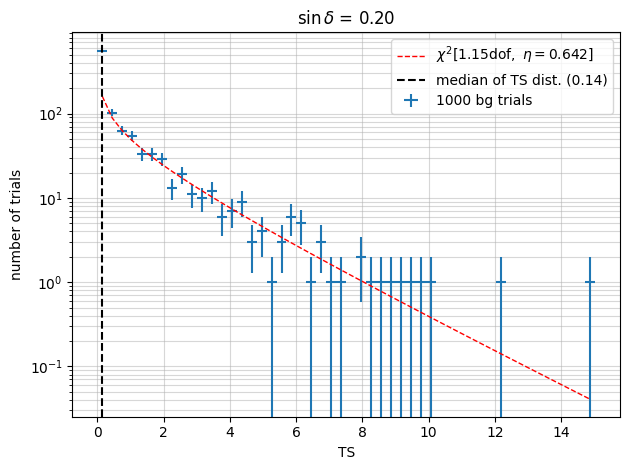

NOTE: Using cached King parameters...


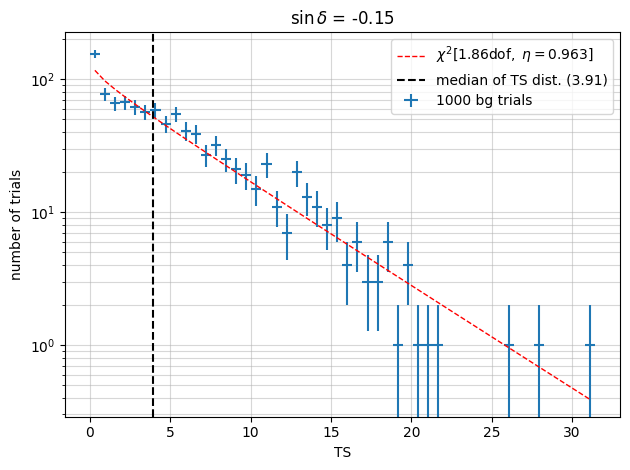

NOTE: Using cached King parameters...


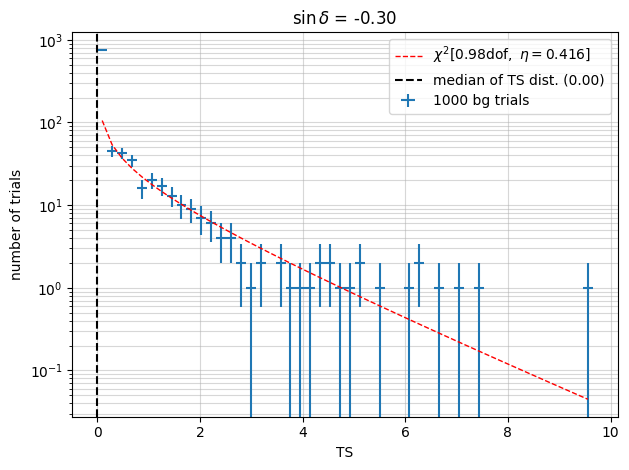

NOTE: Using cached King parameters...


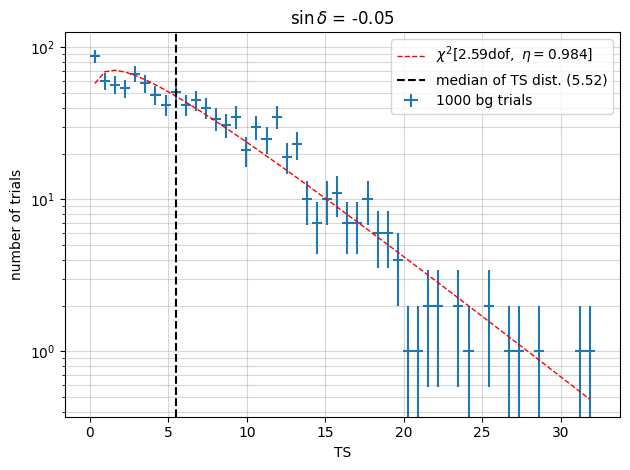

NOTE: Using cached King parameters...


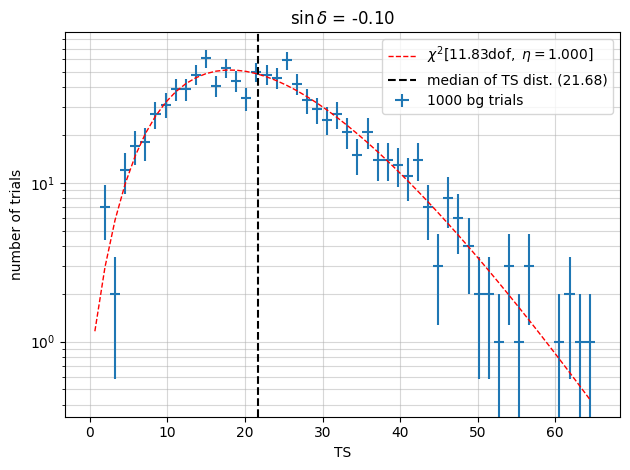

NOTE: Using cached King parameters...


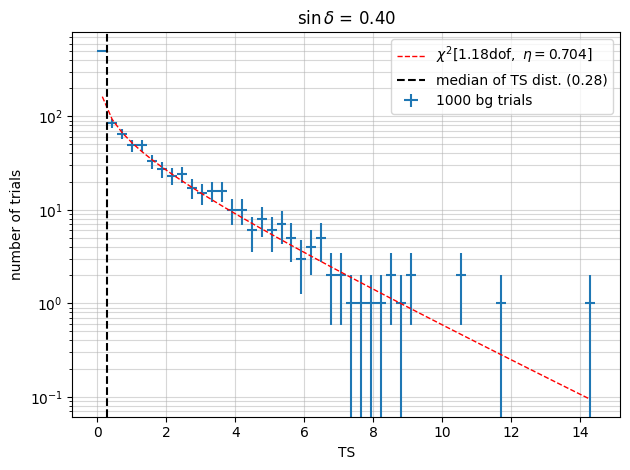

NOTE: Using cached King parameters...


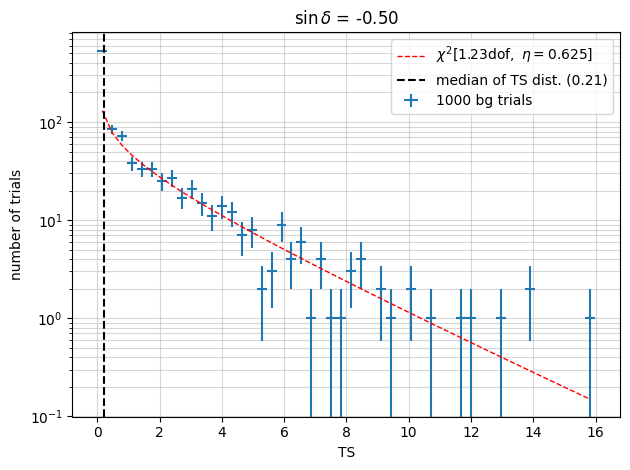

NOTE: Using cached King parameters...


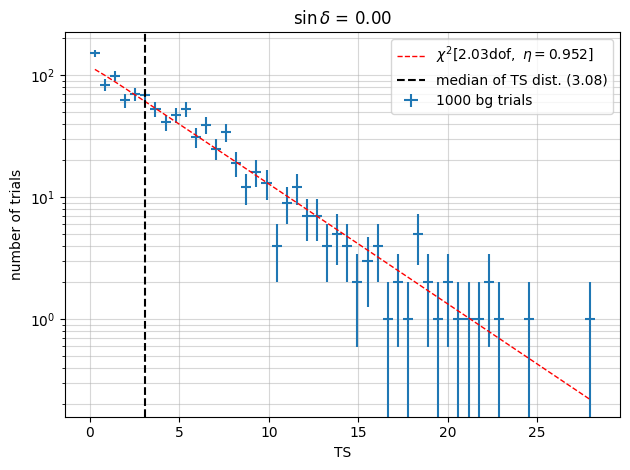

Saved plots to: /data/user/fkrafft/csky_king_tests/equal_p_angErr_fixed_logE_dec/plots


In [21]:
plotting = True
data_dict = {}

for f in files:

    basename = os.path.basename(f)

    match = re.search(
        r"sindec_([-+]?\d*\.?\d+).*?N_(\d+)",
        basename
    )

    if not match:
        continue

    sin_dec = float(match.group(1))
    N = int(match.group(2))

    # skip files with wrong N
    if N != target_N:
        continue
    

    sin_dec = float(match.group(1))
    src = cy.sources(0, np.arcsin(sin_dec), deg = False)
    tr, _, _, _ = restore_king_trial_runner(
        config_path=  os.path.join(input_dir, f"king_trial_runner_config_sindec_{sin_dec}_{file_identifier}.pkl"),
        ana = ana
        )
    arr = np.load(f)

    df = pd.DataFrame(arr)          # optional
    cached_trials = cy.utils.Arrays(arr)
    #apply fits
    bg = cy.dists.Chi2TSD(cached_trials)

    data_dict[sin_dec] = {
        "df": df,
        "cached_trials": cached_trials,
        "bg": bg,
        "tr": tr
    }
    if np.sum(cached_trials["ts"] > 0) == 0:
        continue
    if plotting: 
        fig, ax = plt.subplots()

        h = bg.get_hist(bins= 50)
        hl.plot1d(
            ax,
            h,
            crosses=True,
            label=f"{bg.n_total} bg trials"
        )

        x = h.centers[0]
        norm = h.integrate().values
        ax.grid(which = 'both', alpha = 0.5)
        ax.semilogy(
            x,
            norm * bg.pdf(x),
            lw=1,
            ls="--",
            color = 'red',
            label=rf"$\chi^2[{bg.ndof:.2f}\mathrm{{dof}},\ \eta={bg.eta:.3f}]$"
        )
        ax.axvline(bg.median(), color = 'black', linestyle = 'dashed', label = f'median of TS dist. ({bg.median():.2f})')
        ax.set_xlabel("TS")
        ax.set_ylabel("number of trials")
        ax.set_title("$\sin{\delta}$" + f" = {sin_dec:.2f}")
        ax.legend()
        plt.tight_layout()

        outpath = os.path.join(plot_dir, f"bkg_trials_sin_dec_{sin_dec:.2f}.png")
        fig.savefig(outpath, dpi=200)
        plt.show()
        plt.close(fig)

print(f"Saved plots to: {plot_dir}")

In [9]:
for sin_dec, data in data_dict.items():
    print(f"{sin_dec}:\t {data['bg']}")

0.2:	 Chi2TSD(1000 trials, eta=0.642, ndof=1.154, median=0.142 (from fit 0.145))
-0.15:	 Chi2TSD(1000 trials, eta=0.963, ndof=1.864, median=3.914 (from fit 3.381))
-0.3:	 Chi2TSD(1000 trials, eta=0.416, ndof=0.975, median=0.000 (from fit 0.000))
-0.05:	 Chi2TSD(1000 trials, eta=0.984, ndof=2.595, median=5.519 (from fit 4.929))
-0.1:	 Chi2TSD(1000 trials, eta=1.000, ndof=11.826, median=21.677 (from fit 21.071))
0.4:	 Chi2TSD(1000 trials, eta=0.704, ndof=1.177, median=0.279 (from fit 0.273))
-0.5:	 Chi2TSD(1000 trials, eta=0.625, ndof=1.232, median=0.209 (from fit 0.199))
0.0:	 Chi2TSD(1000 trials, eta=0.952, ndof=2.026, median=3.082 (from fit 2.889))


<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
<>:19: SyntaxWarning: invalid escape sequence '\c'
<>:20: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2223117/2962883655.py:19: SyntaxWarning: invalid escape sequence '\c'
  ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
/tmp/ipykernel_2223117/2962883655.py:20: SyntaxWarning: invalid escape sequence '\s'
  ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)


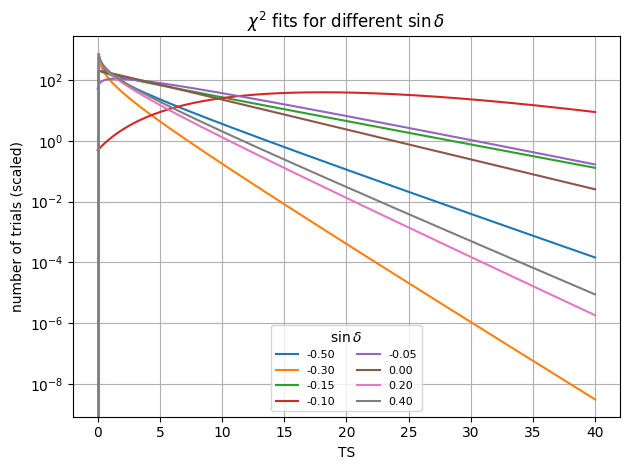

log


In [10]:
fig, ax = plt.subplots()

x = np.linspace(0, 40, 500)

for sin_dec, d in sorted(data_dict.items()):
    bg = d["bg"]

    # normalize like before
    norm = bg.n_total  # or use consistent normalization if preferred

    ax.semilogy(
        x,
        norm * bg.pdf(x),
        label=f"{sin_dec:.2f}"
    )

ax.set_xlabel("TS")
ax.set_ylabel("number of trials (scaled)")
ax.set_title("$\chi^2$ fits for different $\sin{\delta}$")
ax.legend(title="$\sin{\delta}$", ncol=2, fontsize=8)
ax.set_yscale("log")

# Major ticks (10^n)
ax.yaxis.set_major_locator(LogLocator(base=10))

# Minor ticks (2–9 within each decade)
ax.yaxis.set_minor_locator(LogLocator(base=10, subs=np.arange(2, 10) * 0.1))

# Grid styling
ax.grid(which="major", linestyle="-", linewidth=0.8)
ax.grid(which="minor", linestyle=":", linewidth=0.5, alpha=0.7)
plt.tight_layout()
plt.savefig(os.path.join(plot_dir, "summary_chi2.png"), dpi=200)
plt.show()
plt.close(fig)
print(ax.get_yscale())

## Estimate Sensitivity + Discovery Potential

In [45]:
for sin_dec, d in sorted(data_dict.items()):
    trial_runner: cy.trial.TrialRunner = d["tr"]
    bkg = d["bg"]
    with time('ps sensitivity'):
        print(f'Estimating sensitivity for sin(dec) = {sin_dec}')
        sens = trial_runner.find_n_sig(
            # ts, threshold
            bkg.median(), # p = 50%
            # beta, fraction of trials which should exceed the threshold
            0.9, # beta = 90%
            # n_inj step size for initial scan
            n_sig_step=1,
            # this many trials at a time
            batch_size=500,
            # tolerance, as estimated relative error
            tol=.05,
        )
        d["sens"] = sens

Estimating sensitivity for sin(dec) = -0.5
Start time: 2026-05-21 10:21:07.745685
Using 32 cores.
* Starting initial scan for 90% of 50 trials with TS >= 0.209...
  n_sig = 1.000 ... frac = 0.56000
  n_sig = 2.000 ... frac = 0.68000
  n_sig = 3.000 ... frac = 0.70000
  n_sig = 4.000 ... frac = 0.66000
  n_sig = 5.000 ... frac = 0.74000
  n_sig = 6.000 ... frac = 0.66000
  n_sig = 7.000 ... frac = 0.88000
  n_sig = 8.000 ... frac = 0.80000
  n_sig = 9.000 ... frac = 0.86000
  n_sig = 10.000 ... frac = 0.88000
  n_sig = 11.000 ... frac = 0.88000
  n_sig = 12.000 ... frac = 0.84000
  n_sig = 13.000 ... frac = 0.88000
  n_sig = 14.000 ... frac = 0.86000
  n_sig = 15.000 ... frac = 0.98000
* Generating batches of 500 trials...
n_trials | n_inj    7.50   12.00   16.50   21.00   25.50   30.00  |  n_sig(relative error)
500      |         77.6%   86.4%   95.8%   99.0%   99.4%   99.8%  |     13.570 (+/-  4.2%) [spline]
End time: 2026-05-21 10:26:38.665557
Elapsed time: 0:05:30.919872

0:05:30.92

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


   85.8%

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


   92.2%

...

   96.2%

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


   98.5%

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)
/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


   99.5%  |      6.797 (+/-  3.5%) [chi2.cdf]
End time: 2026-05-21 11:15:33.839918
Elapsed time: 0:09:55.099936

0:09:55.100616 elapsed.


In [67]:
sens_dict = {k: v["sens"] for k, v in data_dict.items()}

store data 

In [68]:
def to_jsonable(obj):
    if isinstance(obj, dict):
        return {k: to_jsonable(v) for k, v in obj.items()}
    if isinstance(obj, list):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, tuple):
        return [to_jsonable(v) for v in obj]
    if isinstance(obj, np.ndarray):
        return obj.tolist()
    if isinstance(obj, np.integer):
        return int(obj)
    if isinstance(obj, np.floating):
        x = float(obj)
        if math.isinf(x):
            return "inf" if x > 0 else "-inf"
        if math.isnan(x):
            return "nan"
        return x
    if isinstance(obj, float):
        if math.isinf(obj):
            return "inf" if obj > 0 else "-inf"
        if math.isnan(obj):
            return "nan"
        return obj

    # turn scipy spline/interpolator objects into their class name
    if hasattr(obj, "__class__"):
        module = getattr(obj.__class__, "__module__", "")
        name = obj.__class__.__name__
        if "scipy.interpolate" in module:
            return name

    return obj

In [69]:
json_sens_dict = to_jsonable(sens_dict)
with open(os.path.join(plot_dir, 'king_sensitivity.json'), "w") as f:
    json.dump(json_sens_dict, f)

In [70]:
with open(os.path.join(plot_dir, 'king_sensitivity.json')) as f:
    json_sens_dict = json.load(f, parse_int = float)
    json_sens_dict = {float(k): v for k, v in json_sens_dict.items()}

In [71]:
with open(os.path.join('/data/user/fkrafft/csky_gfu_tests/trials_100k_post2018/plots', 'sensitivity.json')) as f:
    rayleigh_sens_dict = json.load(f, parse_int = float)
    rayleigh_sens_dict = {float(k): v for k, v in json_sens_dict.items()}

In [72]:
""" tss = data_dict[-0.1]["sens"]['tss']
# sort by injected signal strength
n_sigs = sorted(tss.keys())

plt.figure(figsize=(12, 6))

# use bg trials at n_sig = 0 for the median TS line
bg_ts = np.asarray(tss[0.0])
median_ts = np.median(bg_ts)

# background histogram
plt.hist(
    bg_ts,
    bins=40,
    density=True,
    histtype="step",
    linewidth=1.6,
    alpha=0.9,
    label=f"{len(bg_ts)} bg trials"
)

# vertical median line
plt.axvline(
    median_ts,
    linestyle="--",
    linewidth=1.5,
    alpha=0.7,
    label="Median TS"
)

# colored histograms for each n_sig
show = True
for n_sig in n_sigs:
    if show: 
        ts_vals = np.asarray(tss[n_sig])

        plt.hist(
            ts_vals,
            bins=40,
            density=True,
            histtype="step",   # gives the cross/errorbar style
            label=f"n_inj = {n_sig:.1f}"
        )
        show = False
    else: 
        show = True   

plt.yscale("log")
plt.xlabel("TS")
plt.ylabel("Density")
plt.title("Sensitivity, $\sin{\delta} = -0.1$")
plt.legend()
plt.grid(alpha=0.3)
plt.show() """

<>:1: SyntaxWarning: invalid escape sequence '\s'
<>:1: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2223117/4250787868.py:1: SyntaxWarning: invalid escape sequence '\s'
  """ tss = data_dict[-0.1]["sens"]['tss']


' tss = data_dict[-0.1]["sens"][\'tss\']\n# sort by injected signal strength\nn_sigs = sorted(tss.keys())\n\nplt.figure(figsize=(12, 6))\n\n# use bg trials at n_sig = 0 for the median TS line\nbg_ts = np.asarray(tss[0.0])\nmedian_ts = np.median(bg_ts)\n\n# background histogram\nplt.hist(\n    bg_ts,\n    bins=40,\n    density=True,\n    histtype="step",\n    linewidth=1.6,\n    alpha=0.9,\n    label=f"{len(bg_ts)} bg trials"\n)\n\n# vertical median line\nplt.axvline(\n    median_ts,\n    linestyle="--",\n    linewidth=1.5,\n    alpha=0.7,\n    label="Median TS"\n)\n\n# colored histograms for each n_sig\nshow = True\nfor n_sig in n_sigs:\n    if show: \n        ts_vals = np.asarray(tss[n_sig])\n\n        plt.hist(\n            ts_vals,\n            bins=40,\n            density=True,\n            histtype="step",   # gives the cross/errorbar style\n            label=f"n_inj = {n_sig:.1f}"\n        )\n        show = False\n    else: \n        show = True   \n\nplt.yscale("log")\nplt.xlab

In [73]:
""" plt.figure()
plt.scatter(json_sens_dict[-0.1]['info']['n_sigs'], json_sens_dict[-0.1]['info']['CLs'])
plt.ylabel('Fraction TS > Median TS')
plt.xlabel('$n_{inj}$')
outpath = os.path.join(plot_dir, f"sensitivity_n_fraction_sin_dec_-0_1.png")
plt.savefig(outpath, dpi=200)
plt.grid() """

' plt.figure()\nplt.scatter(json_sens_dict[-0.1][\'info\'][\'n_sigs\'], json_sens_dict[-0.1][\'info\'][\'CLs\'])\nplt.ylabel(\'Fraction TS > Median TS\')\nplt.xlabel(\'$n_{inj}$\')\noutpath = os.path.join(plot_dir, f"sensitivity_n_fraction_sin_dec_-0_1.png")\nplt.savefig(outpath, dpi=200)\nplt.grid() '

In [74]:
""" x = sorted(json_sens_dict.keys())
y = [json_sens_dict[k] for k in x]

yerr = [json_sens_dict[k]["n_sig"]*json_sens_dict[k]["n_sig_error"] for k in x]

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize= 3, marker = '.')
plt.xlabel("sin(dec)")
plt.ylabel("n_sig")
plt.grid()
outpath = os.path.join(plot_dir, f"sensitivity_n_sig_summary.png")
plt.savefig(outpath, dpi=200)
plt.show()
 """

' x = sorted(json_sens_dict.keys())\ny = [json_sens_dict[k] for k in x]\n\nyerr = [json_sens_dict[k]["n_sig"]*json_sens_dict[k]["n_sig_error"] for k in x]\n\nplt.figure()\nplt.errorbar(x, y, yerr=yerr, fmt=\'o\', capsize= 3, marker = \'.\')\nplt.xlabel("sin(dec)")\nplt.ylabel("n_sig")\nplt.grid()\noutpath = os.path.join(plot_dir, f"sensitivity_n_sig_summary.png")\nplt.savefig(outpath, dpi=200)\nplt.show()\n '

<>:42: SyntaxWarning: invalid escape sequence '\s'
<>:42: SyntaxWarning: invalid escape sequence '\s'
/tmp/ipykernel_2223117/1798828103.py:42: SyntaxWarning: invalid escape sequence '\s'
  plt.xlabel("$\sin{(\mathrm{dec})}$")


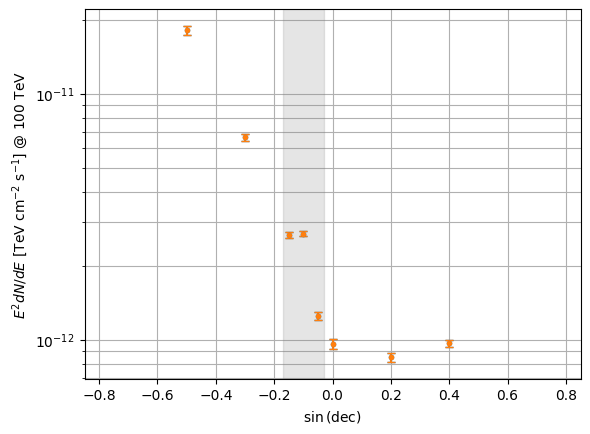

In [75]:
x = sorted(data_dict.keys())

y = []
yerr = []
rayleigh_y = []
rayleigh_yerr = []
for k in x:
    d = data_dict[k]
    tr = d["tr"]
    sens = d["sens"]["n_sig"]
    
    rayleigh_d = rayleigh_sens_dict[k]
    rayleigh_sens = rayleigh_d["n_sig"]

    # percent → absolute error
    n_err = sens * d["sens"]["n_sig_error"]
    
    rayleigh_n_err = rayleigh_sens * rayleigh_d["n_sig_error"]

    # central value
    flux = tr.to_E2dNdE(sens, E0=100, unit=1e3)
    
    rayleigh_flux = tr.to_E2dNdE(rayleigh_sens, E0=100, unit=1e3)
    

    # error (propagated)
    flux_err = tr.to_E2dNdE(sens + n_err, E0=100, unit=1e3) - flux
    
    rayleigh_flux_err = tr.to_E2dNdE(rayleigh_sens + rayleigh_n_err, E0=100, unit=1e3) - rayleigh_flux

    y.append(flux)
    rayleigh_y.append(rayleigh_flux)
    yerr.append(flux_err)
    rayleigh_yerr.append(rayleigh_flux_err)

plt.figure()
plt.yscale('log')
plt.axvspan(-0.17, -0.03, color = 'grey', alpha = 0.2, zorder = 2)
plt.errorbar(x, y, yerr=yerr, fmt = '.', capsize=3,  zorder = 3, label = 'King')
plt.errorbar(x, rayleigh_y, yerr=rayleigh_yerr, fmt = '.', capsize=3,  zorder = 3, label = 'Rayleigh')
#plt.plot(x, y, ls = 'dotted', color = 'grey')
plt.xlabel("$\sin{(\mathrm{dec})}$")
plt.xlim(-0.85, 0.85)
plt.ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
plt.grid(which = 'both', zorder = 1)
outpath = os.path.join(plot_dir, f"sensitivity_flux_summary.png")
plt.savefig(outpath, dpi=200)
plt.show()

In [78]:
print(y)
print(rayleigh_y)

[1.811084002531398e-11, 6.652336765391772e-12, 2.6580179684909203e-12, 2.6977342047274528e-12, 1.2508776913179764e-12, 9.62255386200666e-13, 8.47782735055559e-13, 9.671977203342563e-13]
[1.811084002531398e-11, 6.652336765391772e-12, 2.6580179684909203e-12, 2.6977342047274528e-12, 1.2508776913179764e-12, 9.62255386200666e-13, 8.47782735055559e-13, 9.671977203342563e-13]


In [76]:
for sin_dec, d in sorted(data_dict.items()):
    trial_runner: cy.trial.TrialRunner = d["tr"]
    bkg = d["bg"]
    with time('ps discovery potential'):
        print(f'Estimating discovery potential for sin(dec) = {sin_dec}')
        disc = trial_runner.find_n_sig(
        bkg.isf_nsigma(5), # p = 5 sigma
        0.5, # beta = 50%
        n_sig_step=5, 
        batch_size=500, 
        tol=.05)
        d["disc"] = disc

Estimating discovery potential for sin(dec) = -0.3
Start time: 2026-05-20 09:55:24.587857
Using 10 cores.
* Starting initial scan for 50% of 50 trials with TS >= 24.053...
  n_sig = 5.000 ... frac = 0.06000
  n_sig = 10.000 ... frac = 0.24000
  n_sig = 15.000 ... frac = 0.78000
* Generating batches of 500 trials...
n_trials | n_inj    7.50   12.00   16.50   21.00   25.50   30.00  |  n_sig(relative error)
500      |         12.4%   45.2%   83.8%   95.8%   98.6%   99.8%  |     12.212 (+/-  1.8%) [chi2.cdf]
End time: 2026-05-20 09:55:39.062116
Elapsed time: 0:00:14.474259

0:00:14.475935 elapsed.


In [77]:
disc_dict = {k: v["disc"] for k, v in data_dict.items()}

In [78]:
json_disc_dict = to_jsonable(disc_dict)
with open(os.path.join(plot_dir, 'discovery_potential.json'), "w") as f:
    json.dump(json_disc_dict, f)

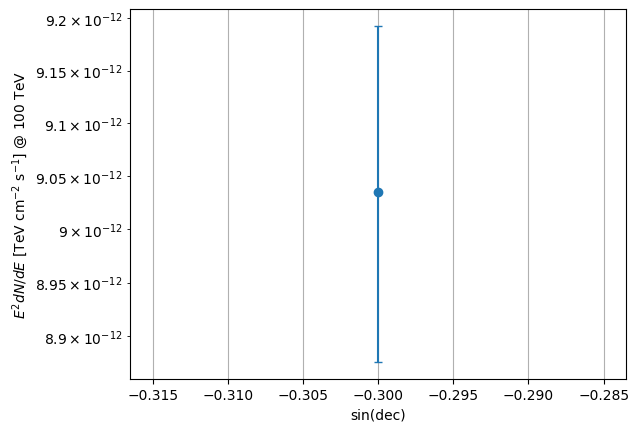

In [79]:
x = sorted(data_dict.keys())

y = []
yerr = []

for k in x:
    d = data_dict[k]
    tr = d["tr"]

    disc = d["disc"]["n_sig"]

    # use /100 if n_sig_error is stored as percent like 5.3
    n_err = disc * d["disc"]["n_sig_error"] 

    flux = tr.to_E2dNdE(disc, E0=100, unit=1e3)
    flux_err = tr.to_E2dNdE(disc + n_err, E0=100, unit=1e3) - flux

    y.append(flux)
    yerr.append(flux_err)

plt.figure()
plt.errorbar(x, y, yerr=yerr, fmt='o', capsize=3)
plt.xlabel("sin(dec)")
plt.ylabel(r"$E^2 dN/dE$ [TeV cm$^{-2}$ s$^{-1}$] @ 100 TeV")
plt.yscale("log")
plt.grid()
outpath = os.path.join(plot_dir, f"discovery_potential_flux_summary.png")
plt.savefig(outpath, dpi=200)
plt.show()

## 3. Test for Bias

One powerful test of analysis readiness is to demonstrate that we can properly fit the parameters of an injected signal. For this we start by getting some batches of signal trials:

In [38]:
n_sigs = np.r_[:101:10]
with time('ps fit bias trials'):
    for sin_dec, data in data_dict.items():
        trials = [get_many_fits_from_trials(tr = data["tr"],
                                            n_trials= 100, 
                                            n_sig=n_sig, 
                                            logging=True, 
                                            mp_cpus = 32,
                                            seed=int(n_sig)) for n_sig in n_sigs]
        
        #We add the true number of events injected for bookkeeping convenience:
        for (n_sig, t) in zip(n_sigs, trials):
            t['ntrue'] = np.repeat(n_sig, len(t))

        #Concatenate the trial batches:
        allt = cy.utils.Arrays.concatenate(trials)
        data_dict[sin_dec]['allt'] = allt

Performing 100 trials with n_sig=0 using 32 cores:
100/100 done
Performing 100 trials with n_sig=10 using 32 cores:
100/100 done
Performing 100 trials with n_sig=20 using 32 cores:
55/100

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


100/100 done
Performing 100 trials with n_sig=30 using 32 cores:
100/100 done
Performing 100 trials with n_sig=40 using 32 cores:
100/100 done
Performing 100 trials with n_sig=50 using 32 cores:
0/100

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


3/100

...

48/100

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


72/100

/home/fkrafft/venvs/icecube-py3v4.4.0/lib/python3.12/site-packages/numba/np/ufunc/dufunc.py:290: RuntimeWarning: divide by zero encountered in _norm
  return super().__call__(*args, **kws)


100/100 done
Performing 100 trials with n_sig=0 using 32 cores:
100/100 done
Performing 100 trials with n_sig=10 using 32 cores:
100/100 done
Performing 100 trials with n_sig=20 using 32 cores:
100/100 done
Performing 100 trials with n_sig=30 using 32 cores:
100/100 done
Performing 100 trials with n_sig=40 using 32 cores:
100/100 done
Performing 100 trials with n_sig=50 using 32 cores:
100/100 done
Performing 100 trials with n_sig=60 using 32 cores:
100/100 done
Performing 100 trials with n_sig=70 using 32 cores:
100/100 done
Performing 100 trials with n_sig=80 using 32 cores:
100/100 done
Performing 100 trials with n_sig=90 using 32 cores:
100/100 done
Performing 100 trials with n_sig=100 using 32 cores:
100/100 done
Performing 100 trials with n_sig=0 using 32 cores:
100/100 done
Performing 100 trials with n_sig=10 using 32 cores:
100/100 done
Performing 100 trials with n_sig=20 using 32 cores:
100/100 done
Performing 100 trials with n_sig=30 using 32 cores:
100/100 done
Performing 10

Plots:

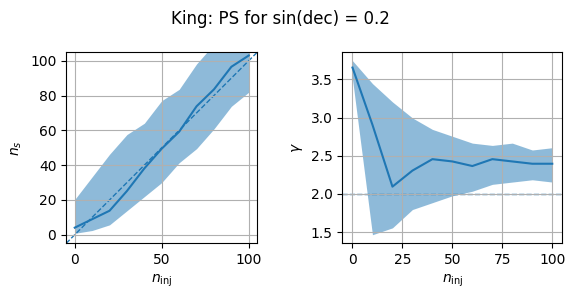

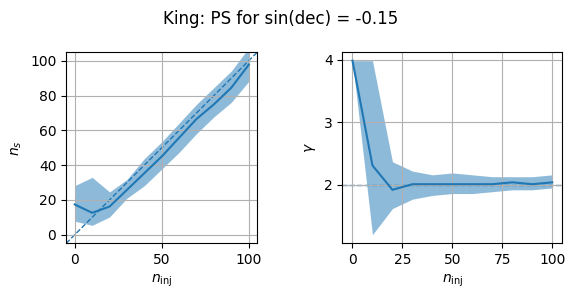

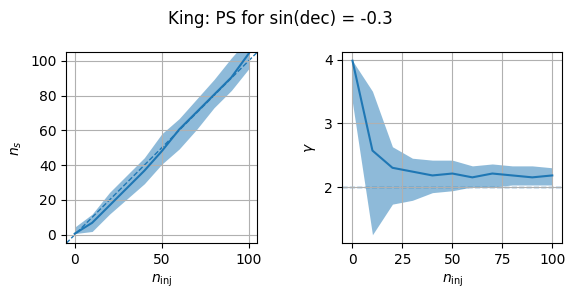

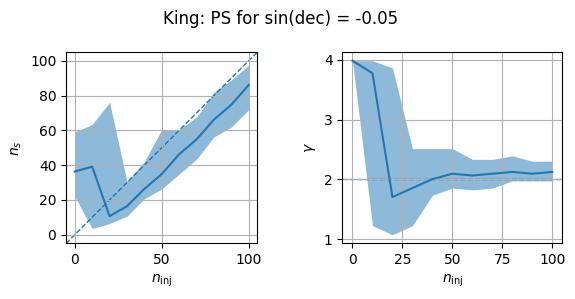

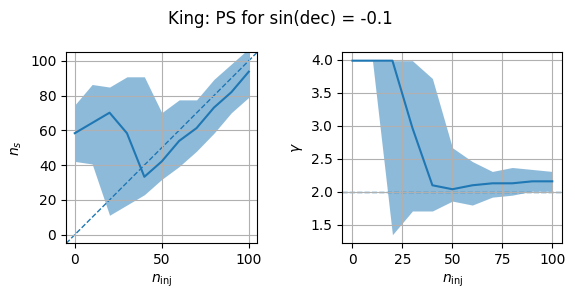

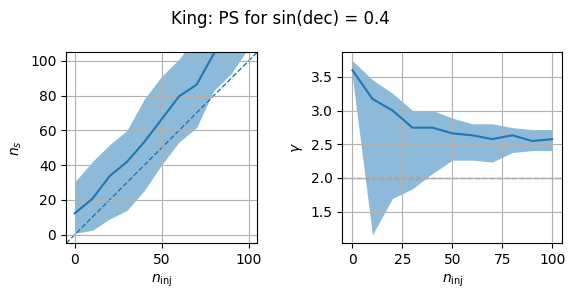

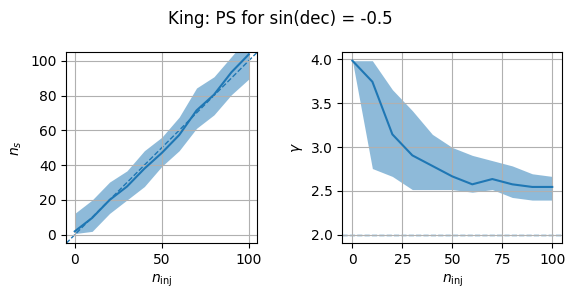

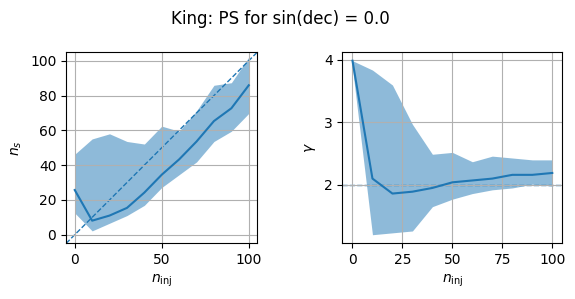

In [39]:
for sin_dec, data in data_dict.items():
    tr = data['tr']
    allt = data['allt']
    
    fig, axs = plt.subplots(1, 2, figsize=(6,3))

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_kw = dict(color='C0', ls='--', lw=1, zorder=-10)
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    ax = axs[0]
    h = hl.hist((allt.ntrue, allt.ns), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')

    lim = ns_bins[[0, -1]]
    ax.set_xlim(ax.set_ylim(lim))
    ax.plot(lim, lim, **expect_kw)
    ax.set_aspect('equal')


    ax = axs[1]
    h = hl.hist((allt.ntrue, allt.gamma), bins=(ns_bins, 100))
    hl.plot1d(ax, h.contain_project(1),errorbands=True, drawstyle='default')
    ax.axhline(expect_gamma, **expect_kw)
    ax.set_xlim(axs[0].get_xlim())

    for ax in axs:
        ax.set_xlabel(r'$n_\text{inj}$')
        ax.grid()
    axs[0].set_ylabel(r'$n_s$')
    axs[1].set_ylabel(r'$\gamma$')
    plt.suptitle(f'King: PS for sin(dec) = {sin_dec}')
    plt.tight_layout()
    plt.savefig(os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.pdf"))

In [40]:
for sin_dec, data in data_dict.items():

    tr = data["tr"]
    allt = data["allt"]

    dns = np.mean(np.diff(n_sigs))
    ns_bins = np.r_[n_sigs - 0.5*dns, n_sigs[-1] + 0.5*dns]
    expect_gamma = tr.sig_injs[0].flux[0].gamma

    out = os.path.join(plot_dir, f"ps_king_sindec{sin_dec}.npz")

    np.savez(
        out,
        sin_dec=sin_dec,
        ntrue=np.asarray(allt.ntrue),
        ns=np.asarray(allt.ns),
        gamma=np.asarray(allt.gamma),
        n_sigs=np.asarray(n_sigs),
        ns_bins=np.asarray(ns_bins),
        expect_gamma=expect_gamma,
    )

load PS from rayleigh, king for comparison

In [41]:
king_dir = Path(plot_dir)

king_files = sorted(king_dir.glob("ps_king_sindec*.npz"))

ps_king_data = {}

for f in king_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_king_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_king_data.keys())

dict_keys([-0.05, -0.1, -0.15, -0.3, -0.5, 0.0, 0.2, 0.4])


In [42]:

rayleigh_dir = Path("/data/user/fkrafft/csky_gfu_tests/trials_100k_post2018/plots")

rayleigh_files = sorted(rayleigh_dir.glob("ps_rayleigh_sindec*.npz"))

ps_rayleigh_data = {}

for f in rayleigh_files:
    d = np.load(f)

    sin_dec = float(d["sin_dec"])

    ps_rayleigh_data[sin_dec] = {
        "ntrue": d["ntrue"],
        "ns": d["ns"],
        "gamma": d["gamma"],
        "ns_bins": d["ns_bins"],
        "expect_gamma": float(d["expect_gamma"]),
    }

print(ps_rayleigh_data.keys())

dict_keys([-0.05, -0.1, -0.15, -0.2, -0.3, -0.5, 0.0, 0.2, 0.4])


In [43]:
def plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=None):
    matching_sindecs = sorted(set(ps_king_data) & set(ps_rayleigh_data))

    for sin_dec in matching_sindecs:
        king = ps_king_data[sin_dec]
        ray = ps_rayleigh_data[sin_dec]

        fig, axs = plt.subplots(
            2, 2,
            figsize=(7, 5),
            sharex="col",
            gridspec_kw={"height_ratios": [3, 1]},
        )

        # ---------- n_s plot ----------
        ax = axs[0, 0]
        rax = axs[1, 0]

        h_king = hl.hist(
            (king["ntrue"], king["ns"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["ns"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        # residual: Rayleigh - King
        res_ns = h_ray.values - h_king.values
        x_ns = h_king.centers[0]

        rax.axhline(0, color="k", lw=1)
        rax.plot(x_ns, res_ns, drawstyle="steps-mid")

        lim = king["ns_bins"][[0, -1]]
        ax.plot(lim, lim, color="C0", ls="--", lw=1, zorder=-10)
        ax.set_xlim(lim)
        ax.set_ylim(lim)
        ax.set_aspect("equal")

        ax.set_ylabel(r"$n_s$")
        rax.set_ylabel("Ray - King")
        rax.set_xlabel(r"$n_\text{inj}$")

        # ---------- gamma plot ----------
        ax = axs[0, 1]
        rax = axs[1, 1]

        h_king = hl.hist(
            (king["ntrue"], king["gamma"]),
            bins=(king["ns_bins"], 100),
        ).contain_project(1)

        h_ray = hl.hist(
            (ray["ntrue"], ray["gamma"]),
            bins=(ray["ns_bins"], 100),
        ).contain_project(1)

        hl.plot1d(ax, h_king, errorbands=True, drawstyle="default", label="King")
        hl.plot1d(ax, h_ray, errorbands=True, drawstyle="default", label="Rayleigh")

        res_gamma = h_ray.values - h_king.values
        x_gamma = h_king.centers[0]

        rax.axhline(0, color="k", lw=1)
        rax.plot(x_gamma, res_gamma, drawstyle="steps-mid")

        ax.axhline(king["expect_gamma"], color="C0", ls="--", lw=1, zorder=-10)
        ax.set_xlim(axs[0, 0].get_xlim())

        ax.set_ylabel(r"$\gamma$")
        rax.set_ylabel("Ray - King")
        rax.set_xlabel(r"$n_\text{inj}$")

        for ax in axs.flat:
            ax.grid()
        axs[0, 0].legend()

        fig.suptitle(f"PS comparison for sin(dec) = {sin_dec}")
        fig.tight_layout()

        if plot_dir is not None:
            fig.savefig(
                f"{plot_dir}/ps_king_vs_rayleigh_sindec{sin_dec}.pdf"
            )

        plt.show()

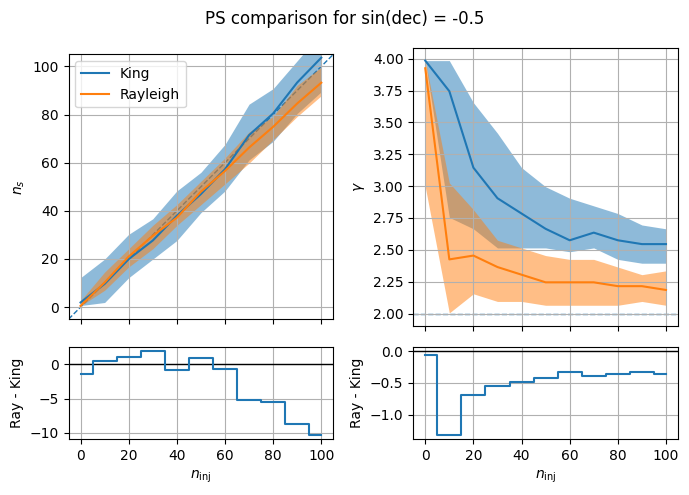

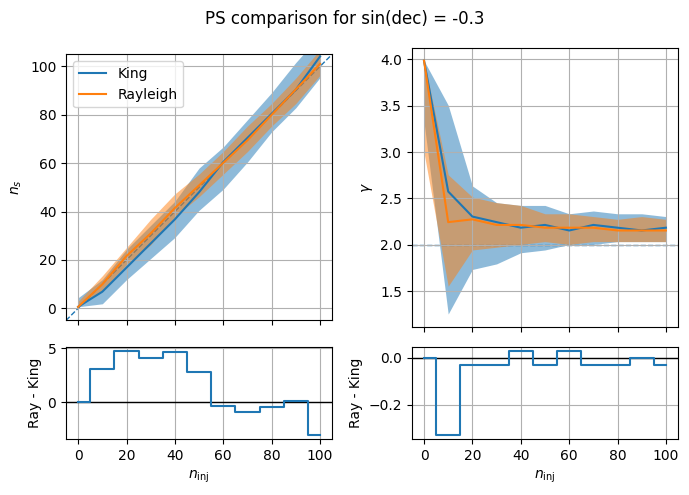

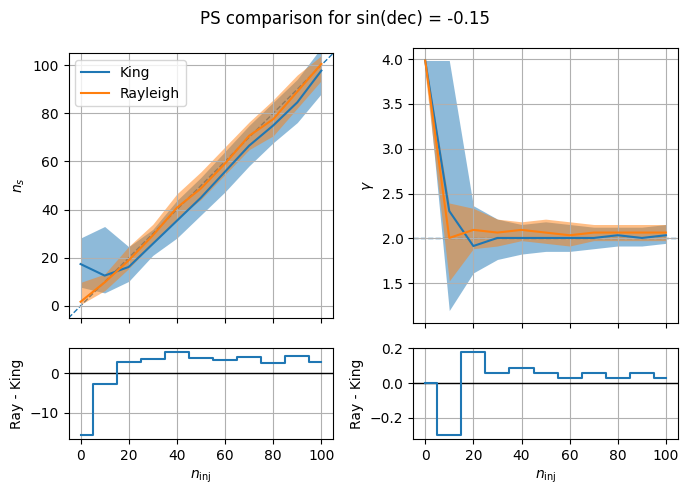

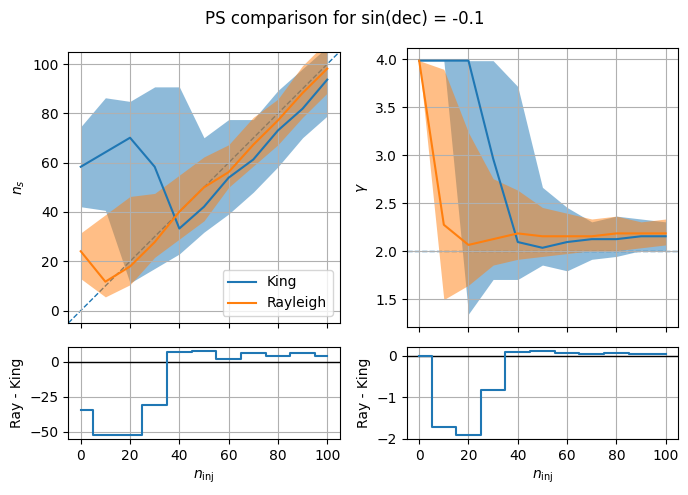

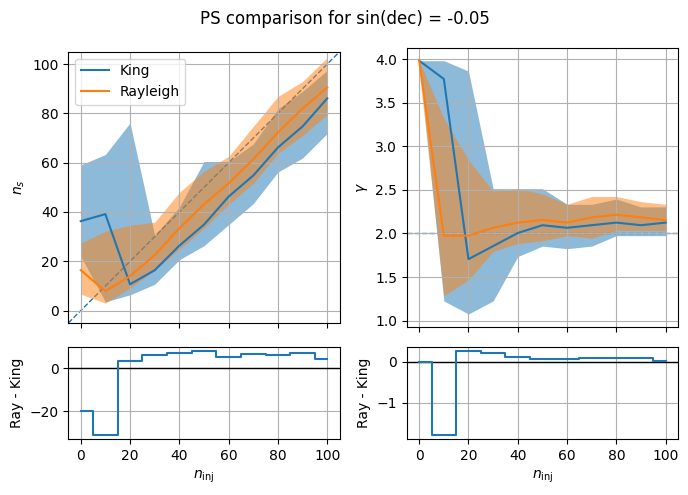

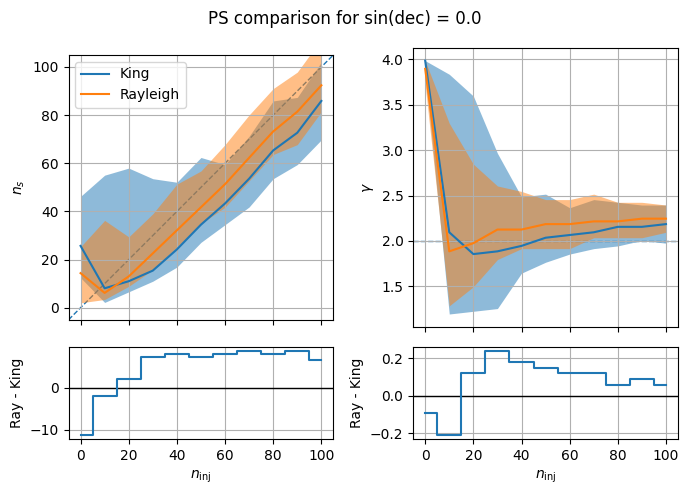

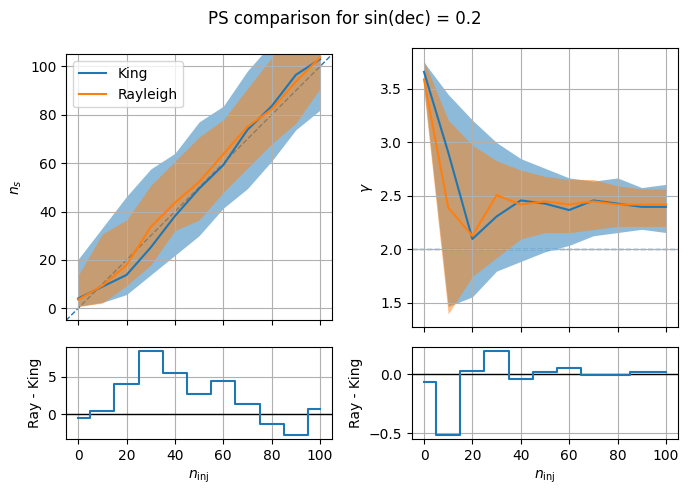

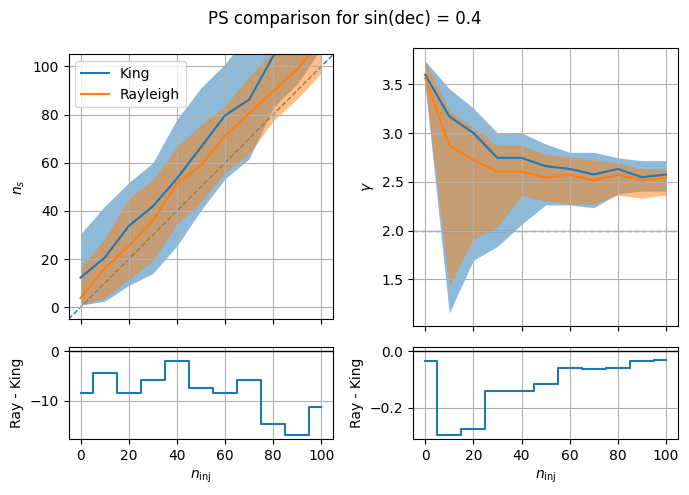

In [44]:
plot_king_vs_rayleigh(ps_king_data, ps_rayleigh_data, plot_dir=plot_dir)